In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

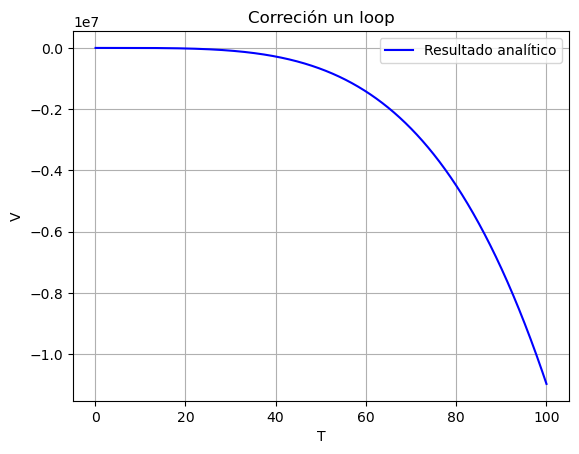

In [5]:
lamda = 0.5
m = 0.1
phi = ((6*m**2)/lamda)**(1/2)
M = m**2 + (lamda*(phi**2))/2

gamma = 0.57721566490153286060
c = 3/2+2*np.log(4*np.pi)-2*gamma

T = np.linspace(0.1, 100, 10000)

V = -(T**4*np.pi**2)/(90)+(M**2*T**2)/(24)-(T*M**3)/(12*np.pi)-(M**4*np.log(M**2/T**2))/(64*np.pi**2)+(c*M**2)/(64*np.pi**2)

plt.plot(T, V, label='Resultado analítico', color='blue')
plt.title('Correción un loop')
plt.xlabel('T')
plt.ylabel('V')
plt.grid(True)
plt.legend()
plt.show()

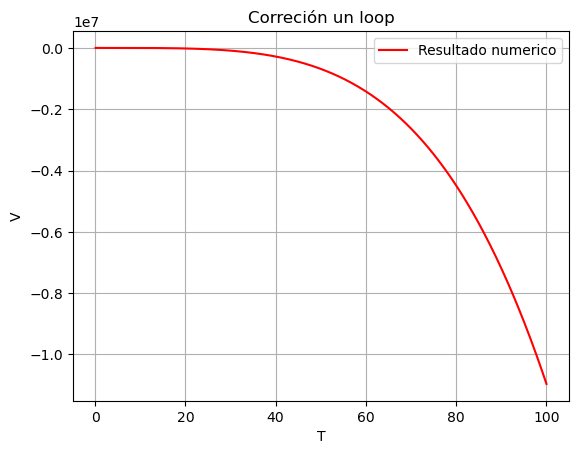

In [39]:
t=1
a = M/t
resultados = []

for t in T:
    def I(x):
        return (t**4/(2*np.pi**2))*x**2*np.log(1-np.exp(-(x**2+a**2)**(1/2)))
    resultado, _ = quad(I, 0, np.inf)
    resultados.append(resultado)

resultados = np.array(resultados)


plt.plot(T, resultados,label='Resultado numerico', color='red')
plt.title('Correción un loop')
plt.xlabel('T')
plt.ylabel('V')
plt.grid(True)
plt.legend()
plt.show()

In [19]:
##a = M/t
##resultados = []

##def I(x,t):
    ##return (t**4/(2*np.pi**2))*x**2*np.log(1-np.exp(-(x**2+a**2)**(1/2)))

##for t in T:
    ##def Ix(x):
        ##return I(x,t)
    ##resultado, _ = quad(Ix, 0, np.inf)
    ##resultados.append(resultado)

##resultados = np.array(resultados)

##plt.plot(T, resultados,label='Resultado numerico', color='orange')
##plt.title('Correción un loop')
##plt.xlabel('T')
##plt.ylabel('V')
##plt.grid(True)
##plt.legend()
##plt.show()

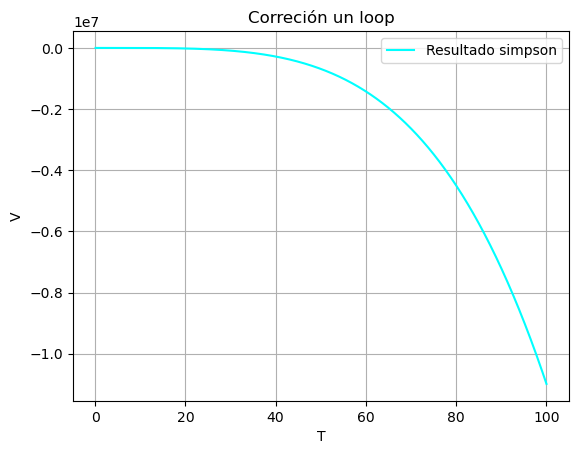

In [37]:
import numpy as np
import matplotlib.pyplot as plt
#Simpson
a_s = 0
b_s = 500
n_s = 1000
h_s = (b_s-a_s)/n_s
x_s = np.linspace(a_s, b_s, n_s+1)
T = np.linspace(0.1, 100, 10000)

V_s=[]

for t in T:
    def I(x_s):
        return (t**4/(2*np.pi**2))*x_s**2*np.log(1-np.exp(-(x_s**2+(0.04/t)**2)**(1/2)))

    y_s = I(x_s)
    suma=0
    
    if n_s % 2 != 0:
        print('Las subdiviciones no son pares')
    else:
        extremos = y_s[0]+ y_s[-1]
        
        #todo lo de enmedio
        for i in range(1,n_s):
            if i % 2 == 0:
                suma = suma + 2 * y_s[i] 
            else:
                suma = suma + 4 * y_s[i] 
                
    integral= (h_s/3)*(extremos + suma)
    V_s.append(integral)

V_s = np.array(V_s)

plt.plot(T, V_s ,label='Resultado simpson', color='cyan')
plt.title('Correción un loop')
plt.xlabel('T')
plt.ylabel('V')
plt.grid(True)
plt.legend()
plt.show()

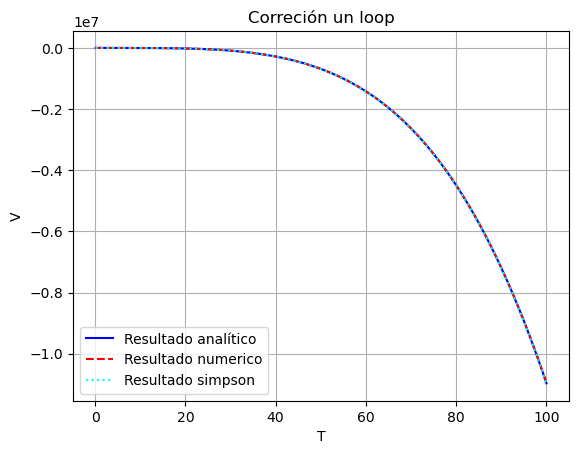

In [35]:
plt.plot(T, V, label='Resultado analítico', color='blue')
plt.plot(T, resultados, '--' ,label='Resultado numerico', color='red')
plt.plot(T, V_s , ':',label='Resultado simpson', color='cyan')
plt.title('Correción un loop')
plt.xlabel('T')
plt.ylabel('V')
plt.grid(True)
plt.legend()

plt.show()

In [17]:
print(type(V))

<class 'numpy.ndarray'>
